In [ ]:
import squidpy as sq
import numpy as np
from src import utils
import spatialdata_io as sio
import scanpy as sc

quick showcase how to read Xenium files via spatialdata-io and how to extract the anndata table. Usually you would convert the sdata object to zarr for much more efficient use but since we don't need images and only care about the count matrix, the adata object suffices.

In [ ]:
sdata = sio.xenium("Xenium_Human_skin")

In [3]:
sdata

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 20294, 42748), (4, 10147, 21374), (4, 5073, 10687), (4, 2536, 5343), (4, 1268, 2671)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
│     └── 'nucleus_labels': DataTree[yx] (20294, 42748), (10147, 21374), (5073, 10687), (2536, 5343), (1268, 2671)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (112551, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (112551, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (109795, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (112551, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (S

In [ ]:
adata = sdata.tables["table"]
adata.write_h5ad("Human_skin_Xenium.h5ad")

In [3]:
adata = sc.read_h5ad("Human_Skin_Xenium.h5ad")

let's begin with overview of distance statistics

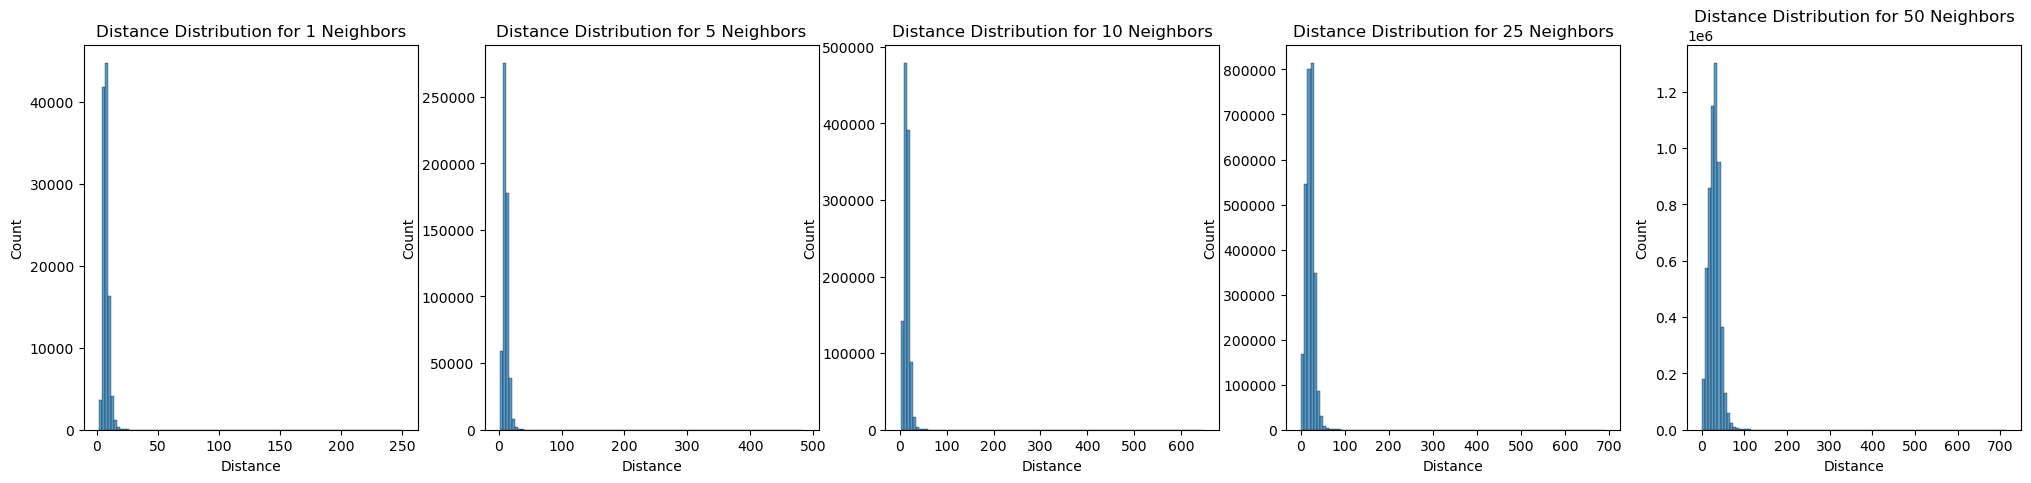

In [5]:
utils.plot_dist_histogram(adata, n_neighs_range=[1, 5, 10, 25, 50], bins=100)

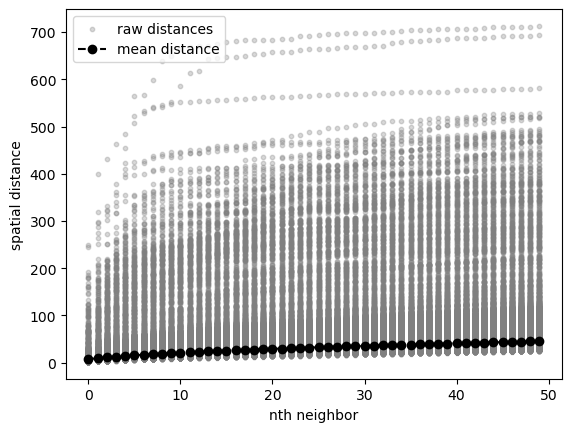

In [6]:
utils.plot_dist_by_neigh(adata, distances_key="50_neighbors_distances")

In [12]:
radii = np.arange(0.0,100.0, 10.0)
utils.get_neighs_by_radius(adata, radii)

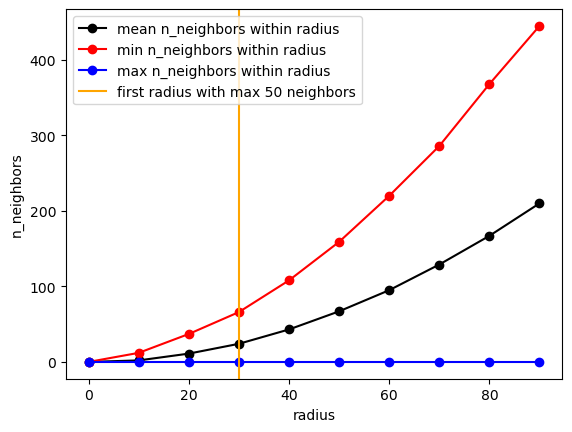

In [10]:
utils.plot_neighs_by_radius(adata)

As you can see it can happen that no matter which radius you pick, there will always be cells with 0 neighbors within that radius. This is due to outliers!

In [13]:
adata.obs["z_score"] = (adata.obs['max_cells_in_radius'].values - adata.obs['max_cells_in_radius'].values.mean())/adata.obs['max_cells_in_radius'].values.var()

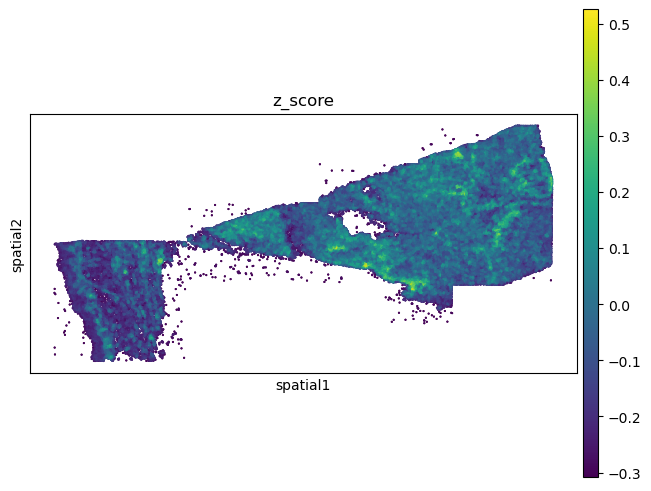

In [14]:
sq.pl.spatial_scatter(adata, color="z_score",shape=None)

Clearly we can observe regions of varying density.